In [2]:
import pandas as pd

train = pd.read_csv('/content/churn-bigml-80.csv')
test = pd.read_csv('/content/churn-bigml-20.csv')

print(train.head())
print(train.columns)
print(train.shape)

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load datasets
train = pd.read_csv('/content/churn-bigml-80.csv')
test = pd.read_csv('/content/churn-bigml-20.csv')

# Encode categorical columns
le = LabelEncoder()

for col in ['State', 'International plan', 'Voice mail plan']:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# Features and target
X_train = train.drop('Churn', axis=1)
y_train = train['Churn']

X_test = test.drop('Churn', axis=1)
y_test = test['Churn']

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Logistic Regression
Accuracy: 0.8590704647676162
Precision: 0.5161290322580645
Recall: 0.16842105263157894
F1 Score: 0.25396825396825395

 Decision Tree
Accuracy: 0.9175412293853074
Precision: 0.7040816326530612
Recall: 0.7263157894736842
F1 Score: 0.7150259067357513

 Random Forest
Accuracy: 0.9460269865067467
Precision: 0.9538461538461539
Recall: 0.6526315789473685
F1 Score: 0.775


In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best Score: 0.9456123727777271


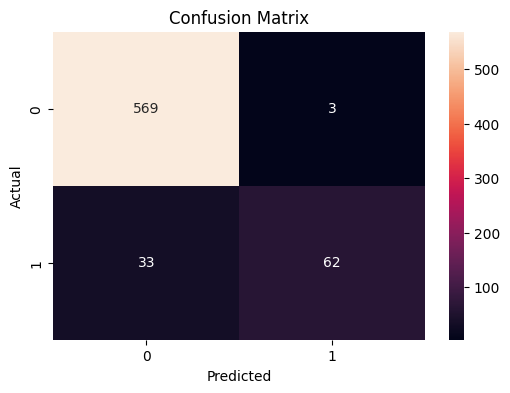

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

best_model = RandomForestClassifier(**grid.best_params_, random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()